In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import random
import pandas as pd
from sklearn.model_selection import train_test_split

In [ ]:
SEED = 42
random.seed(SEED)

In [ ]:
dataset_path = "/content/drive/MyDrive/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"

In [ ]:
classes = sorted([
    cls for cls in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, cls))
])
print("Classes Found:\n")
print(classes)

Classes Found:

['Cyst', 'Normal', 'Stone', 'Tumor']


In [ ]:
all_filepaths = []
all_labels = []

valid_extensions = (
    '.png',
    '.jpg',
    '.jpeg',
    '.bmp'
)

for cls in classes:

    class_path = os.path.join(dataset_path, cls)

    images = [

        img for img in os.listdir(class_path)

        if img.lower().endswith(valid_extensions)
    ]

    print(f"{cls} --> {len(images)} images")

    for img in images:

        full_path = os.path.join(class_path, img)

        all_filepaths.append(full_path)

        all_labels.append(cls)

Cyst --> 3709 images
Normal --> 5077 images
Stone --> 1377 images
Tumor --> 2283 images


In [ ]:
df = pd.DataFrame({
    "filepath": all_filepaths,
    "label": all_labels
})
print("\nTotal Images:", len(df))


Total Images: 12446


In [ ]:
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=SEED
)
# Reset Index
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [ ]:
save_dir = "/content/drive/MyDrive/Kidney_CSV_Splits"

os.makedirs(save_dir, exist_ok=True)

train_csv_path = os.path.join(save_dir, "train.csv")

test_csv_path = os.path.join(save_dir, "test.csv")

train_df.to_csv(train_csv_path, index=False)

test_df.to_csv(test_csv_path, index=False)

In [ ]:
print("\n===================================")
print("CSV Split Created Successfully!")
print("===================================")

print(f"\nTrain CSV Saved At:\n{train_csv_path}")

print(f"\nTest CSV Saved At:\n{test_csv_path}")

print("\nTrain Size:", len(train_df))
print("Test Size :", len(test_df))



CSV Split Created Successfully!

Train CSV Saved At:
/content/drive/MyDrive/Kidney_CSV_Splits/train.csv

Test CSV Saved At:
/content/drive/MyDrive/Kidney_CSV_Splits/test.csv

Train Size: 9956
Test Size : 2490


In [ ]:
print("\n===================================")
print("TRAIN CLASS DISTRIBUTION")
print("===================================\n")

print(train_df["label"].value_counts())

print("\n===================================")
print("TEST CLASS DISTRIBUTION")
print("===================================\n")

print(test_df["label"].value_counts())


TRAIN CLASS DISTRIBUTION

label
Normal    4061
Cyst      2967
Tumor     1826
Stone     1102
Name: count, dtype: int64

TEST CLASS DISTRIBUTION

label
Normal    1016
Cyst       742
Tumor      457
Stone      275
Name: count, dtype: int64


In [ ]:
summary_df = pd.DataFrame({

    "Train_Count": train_df["label"].value_counts(),

    "Test_Count": test_df["label"].value_counts()
})

summary_path = os.path.join(
    save_dir,
    "split_summary.csv"
)

summary_df.to_csv(summary_path)

print(f"\nSummary CSV Saved At:\n{summary_path}")


Summary CSV Saved At:
/content/drive/MyDrive/Kidney_CSV_Splits/split_summary.csv


In [ ]:
!pip install -q open_clip_torch peft timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.9 MB/s eta 0:00:00


In [ ]:
import os
import copy
import time
import numpy as np
import pandas as pd

from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

import open_clip

from peft import (
    LoraConfig,
    get_peft_model
)


In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print("Using Device:", device)

Using Device: cuda


In [ ]:
train_csv = "/content/drive/MyDrive/Kidney_CSV_Splits/train.csv"
test_csv = "/content/drive/MyDrive/Kidney_CSV_Splits/test.csv"

In [ ]:
train_df = pd.read_csv(train_csv)

test_df = pd.read_csv(test_csv)

print("Train Samples:", len(train_df))
print("Test Samples :", len(test_df))

Train Samples: 9956
Test Samples : 2490


In [ ]:
classes = sorted(train_df["label"].unique())
class_to_idx = {
    cls:i for i, cls in enumerate(classes)
}
idx_to_class = {
    i:cls for cls, i in class_to_idx.items()
}
print("\nClasses:")
print(classes)


Classes:
['Cyst', 'Normal', 'Stone', 'Tumor']


In [ ]:
class KidneyDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.df = dataframe

        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        img_path = self.df.iloc[idx]["filepath"]

        label = self.df.iloc[idx]["label"]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = class_to_idx[label]

        return image, label

In [ ]:
train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [ ]:
train_dataset = KidneyDataset(
    train_df,
    transform=train_transform
)

test_dataset = KidneyDataset(
    test_df,
    transform=test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2
)

In [ ]:
clip_model, _, preprocess = open_clip.create_model_and_transforms(
    'ViT-B-32',
    pretrained='openai'
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


In [ ]:
lora_config = LoraConfig(

    r=8,

    lora_alpha=16,

    target_modules=[
        "out_proj",
        "c_fc",
        "c_proj"
    ],

    lora_dropout=0.1,

    bias="none"
)

In [ ]:
trainable_params = 0
all_params = 0

for param in clip_model.visual.parameters():

    num_params = param.numel()

    all_params += num_params

    if param.requires_grad:
        trainable_params += num_params

print(f"\nTrainable Params: {trainable_params:,}")

print(f"Total Params: {all_params:,}")

print(
    f"Trainable %: {100 * trainable_params / all_params:.4f}%"
)


Trainable Params: 87,849,216
Total Params: 87,849,216
Trainable %: 100.0000%


In [ ]:
for name, param in clip_model.visual.named_parameters():
    if param.requires_grad:
        print(name)

class_embedding
positional_embedding
proj
conv1.weight
ln_pre.weight
ln_pre.bias
transformer.resblocks.0.ln_1.weight
transformer.resblocks.0.ln_1.bias
transformer.resblocks.0.attn.in_proj_weight
transformer.resblocks.0.attn.in_proj_bias
transformer.resblocks.0.attn.out_proj.weight
transformer.resblocks.0.attn.out_proj.bias
transformer.resblocks.0.ln_2.weight
transformer.resblocks.0.ln_2.bias
transformer.resblocks.0.mlp.c_fc.weight
transformer.resblocks.0.mlp.c_fc.bias
transformer.resblocks.0.mlp.c_proj.weight
transformer.resblocks.0.mlp.c_proj.bias
transformer.resblocks.1.ln_1.weight
transformer.resblocks.1.ln_1.bias
transformer.resblocks.1.attn.in_proj_weight
transformer.resblocks.1.attn.in_proj_bias
transformer.resblocks.1.attn.out_proj.weight
transformer.resblocks.1.attn.out_proj.bias
transformer.resblocks.1.ln_2.weight
transformer.resblocks.1.ln_2.bias
transformer.resblocks.1.mlp.c_fc.weight
transformer.resblocks.1.mlp.c_fc.bias
transformer.resblocks.1.mlp.c_proj.weight
transformer

In [ ]:
for param in clip_model.visual.parameters():
    param.requires_grad = False

In [ ]:
for name, param in clip_model.visual.named_parameters():
    if "lora" in name.lower():
        param.requires_grad = True

In [ ]:
cnn_model = models.efficientnet_b0(
    weights="DEFAULT"
)
cnn_features = cnn_model.classifier[1].in_features
cnn_model.classifier = nn.Identity()

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 187MB/s]


In [ ]:
class HybridModel(nn.Module):

    def __init__(self):

        super(HybridModel, self).__init__()

        self.clip_visual = clip_model.visual

        self.cnn = cnn_model

        # Projection Layers
        self.clip_proj = nn.Linear(512, 256)

        self.cnn_proj = nn.Linear(cnn_features, 256)

        # Attention Fusion
        self.attention = nn.Sequential(

            nn.Linear(512, 512),

            nn.ReLU(),

            nn.Linear(512, 512),

            nn.Softmax(dim=1)
        )

        # Classifier
        self.classifier = nn.Sequential(

            nn.Linear(512, 256),

            nn.BatchNorm1d(256),

            nn.GELU(),

            nn.Dropout(0.3),

            nn.Linear(256, 128),

            nn.BatchNorm1d(128),

            nn.GELU(),

            nn.Dropout(0.2),

            nn.Linear(128, len(classes))
        )

    def forward(self, x):

        # CLIP Features
        clip_feat = self.clip_visual(x)

        clip_feat = self.clip_proj(clip_feat)

        # CNN Features
        cnn_feat = self.cnn(x)

        cnn_feat = self.cnn_proj(cnn_feat)

        # Fusion
        fused = torch.cat(
            [clip_feat, cnn_feat],
            dim=1
        )

        # Attention Fusion
        fused = torch.cat([clip_feat, cnn_feat], dim=1)

        # Classification
        output = self.classifier(fused)

        return output, fused

In [ ]:
model = HybridModel().to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [ ]:
patience = 3
best_val_loss = np.inf
counter = 0
best_model_wts = copy.deepcopy(
    model.state_dict()
)

In [ ]:
history = {

    "epoch": [],

    "train_loss": [],
    "train_acc": [],

    "test_loss": [],
    "test_acc": [],

    "precision": [],
    "recall": [],
    "specificity": []
}

In [ ]:
all_features = []
all_labels = []
all_predictions = []

In [ ]:
scaler = torch.amp.GradScaler('cuda')

In [ ]:
def train_one_epoch():

    model.train()

    running_loss = 0

    preds_all = []

    labels_all = []

    for images, labels in tqdm(train_loader):

        images = images.to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast(device_type='cuda'):

          outputs, features = model(images)

          loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        preds_all.extend(
            preds.cpu().numpy()
        )

        labels_all.extend(
            labels.cpu().numpy()
        )

    epoch_loss = running_loss / len(train_loader)

    epoch_acc = accuracy_score(
        labels_all,
        preds_all
    )

    return epoch_loss, epoch_acc

In [ ]:
def evaluate():

    model.eval()

    running_loss = 0

    preds_all = []

    labels_all = []

    features_all = []

    with torch.no_grad():

        for images, labels in tqdm(test_loader):

            images = images.to(device)

            labels = labels.to(device)

            outputs, features = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            preds_all.extend(
                preds.cpu().numpy()
            )

            labels_all.extend(
                labels.cpu().numpy()
            )

            features_all.extend(
                features.cpu().numpy()
            )

    epoch_loss = running_loss / len(test_loader)

    epoch_acc = accuracy_score(
        labels_all,
        preds_all
    )

    precision = precision_score(
        labels_all,
        preds_all,
        average='weighted'
    )

    recall = recall_score(
        labels_all,
        preds_all,
        average='weighted'
    )

    cm = confusion_matrix(
        labels_all,
        preds_all
    )

    specificities = []

    for i in range(len(cm)):

        TP = cm[i, i]

        FN = np.sum(cm[i, :]) - TP

        FP = np.sum(cm[:, i]) - TP

        TN = np.sum(cm) - (TP + FN + FP)

        specificity = TN / (TN + FP + 1e-8)

        specificities.append(specificity)

    # Average Specificity
    specificity = np.mean(specificities)

    return (

        epoch_loss,

        epoch_acc,

        precision,

        recall,

        specificity,

        cm,

        labels_all,

        preds_all,

        features_all
    )

In [ ]:
epochs = 20

for epoch in range(epochs):

    print(f"\nEpoch {epoch+1}/{epochs}")

    start_time = time.time()

    # TRAIN
    train_loss, train_acc = train_one_epoch()

    # EVALUATE
    (
        test_loss,
        test_acc,
        precision,
        recall,
        specificity,
        cm,
        y_true,
        y_pred,
        feature_vectors

    ) = evaluate()

    # STORE METRICS
    history["epoch"].append(epoch+1)

    history["train_loss"].append(train_loss)

    history["train_acc"].append(train_acc)

    history["test_loss"].append(test_loss)

    history["test_acc"].append(test_acc)

    history["precision"].append(precision)

    history["recall"].append(recall)

    history["specificity"].append(specificity)

    # SAVE FEATURES
    all_features.extend(feature_vectors)

    all_labels.extend(y_true)

    all_predictions.extend(y_pred)

    # PRINT RESULTS
    print(f"\nTrain Loss : {train_loss:.4f}")

    print(f"Train Acc  : {train_acc:.4f}")

    print(f"Test Loss  : {test_loss:.4f}")

    print(f"Test Acc   : {test_acc:.4f}")

    print(f"Precision  : {precision:.4f}")

    print(f"Recall     : {recall:.4f}")

    print(f"Specificity   : {specificity:.4f}")

    # EARLY STOPPING
    if test_loss < best_val_loss:

        best_val_loss = test_loss

        best_model_wts = copy.deepcopy(
            model.state_dict()
        )

        counter = 0

        print("\nValidation Loss Improved!")

    else:

        counter += 1

        print(
            f"\nEarly Stopping Counter: {counter}/{patience}"
        )

        if counter >= patience:

            print("\nEarly Stopping Triggered!")

            break

    epoch_time = time.time() - start_time

    print(f"\nEpoch Time: {epoch_time:.2f} sec")


Epoch 1/20


100%|██████████| 312/312 [00:24<00:00, 12.66it/s]



Train Loss : 0.1178
Train Acc  : 0.9719
Test Loss  : 0.0154
Test Acc   : 0.9996
Precision  : 0.9996
Recall     : 0.9996
Specificity   : 0.9999

Validation Loss Improved!

Epoch Time: 175.58 sec

Epoch 2/20


100%|██████████| 312/312 [00:23<00:00, 13.31it/s]



Train Loss : 0.0712
Train Acc  : 0.9827
Test Loss  : 0.0195
Test Acc   : 0.9960
Precision  : 0.9960
Recall     : 0.9960
Specificity   : 0.9985

Early Stopping Counter: 1/3

Epoch Time: 170.73 sec

Epoch 3/20


...


Train Loss : 0.0106
Train Acc  : 0.9970
Test Loss  : 0.0006
Test Acc   : 1.0000
Precision  : 1.0000
Recall     : 1.0000
Specificity   : 1.0000

Validation Loss Improved!

Epoch Time: 167.42 sec

Epoch 19/20


100%|██████████| 312/312 [00:23<00:00, 13.03it/s]



Train Loss : 0.0190
Train Acc  : 0.9970
Test Loss  : 0.0025
Test Acc   : 0.9992
Precision  : 0.9992
Recall     : 0.9992
Specificity   : 0.9997

Early Stopping Counter: 1/3

Epoch Time: 168.67 sec

Epoch 20/20


100%|██████████| 312/312 [00:24<00:00, 12.82it/s]


Train Loss : 0.0201
Train Acc  : 0.9967
Test Loss  : 0.0032
Test Acc   : 1.0000
Precision  : 1.0000
Recall     : 1.0000
Specificity   : 1.0000

Early Stopping Counter: 2/3

Epoch Time: 168.53 sec


In [ ]:
model.load_state_dict(best_model_wts)

<All keys matched successfully>

In [ ]:
torch.save(
    model.state_dict(),
    "/content/best_hybrid_model.pth"
)

print("\nBest Model Saved!")



Best Model Saved!


In [ ]:
metrics_df = pd.DataFrame(history)

metrics_df.to_csv(
    "/content/training_metrics.csv",
    index=False
)

print("\nTraining Metrics CSV Saved!")


Training Metrics CSV Saved!


In [ ]:
cm_df = pd.DataFrame(cm)

cm_df.to_csv(
    "/content/confusion_matrix.csv",
    index=False
)

print("\nConfusion Matrix Saved!")


Confusion Matrix Saved!


In [ ]:

pred_df = pd.DataFrame({

    "True_Label": all_labels,

    "Predicted_Label": all_predictions
})

pred_df.to_csv(
    "/content/predictions.csv",
    index=False
)

print("\nPredictions CSV Saved!")


Predictions CSV Saved!


In [ ]:

features_df = pd.DataFrame(all_features)

features_df["label"] = all_labels

features_df["prediction"] = all_predictions

features_df.to_csv(
    "/content/feature_embeddings.csv",
    index=False
)

print("\nFeature Embeddings Saved!")


Feature Embeddings Saved!


In [ ]:
print("\nClassification Report:\n")

print(

    classification_report(

        y_true,

        y_pred,

        target_names=classes
    )
)


Classification Report:

              precision    recall  f1-score   support

        Cyst       1.00      1.00      1.00       742
      Normal       1.00      1.00      1.00      1016
       Stone       1.00      1.00      1.00       275
       Tumor       1.00      1.00      1.00       457

    accuracy                           1.00      2490
   macro avg       1.00      1.00      1.00      2490
weighted avg       1.00      1.00      1.00      2490



<Figure size 800x800 with 0 Axes>

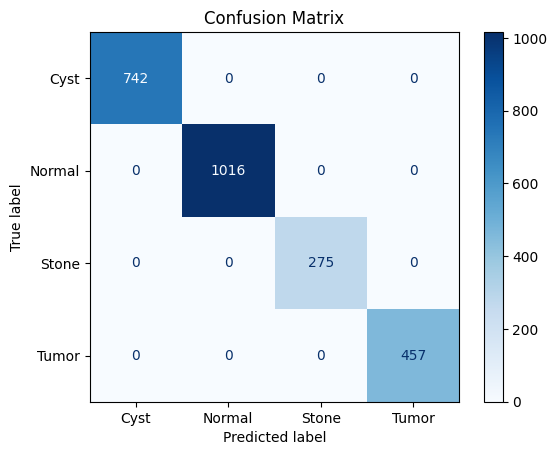

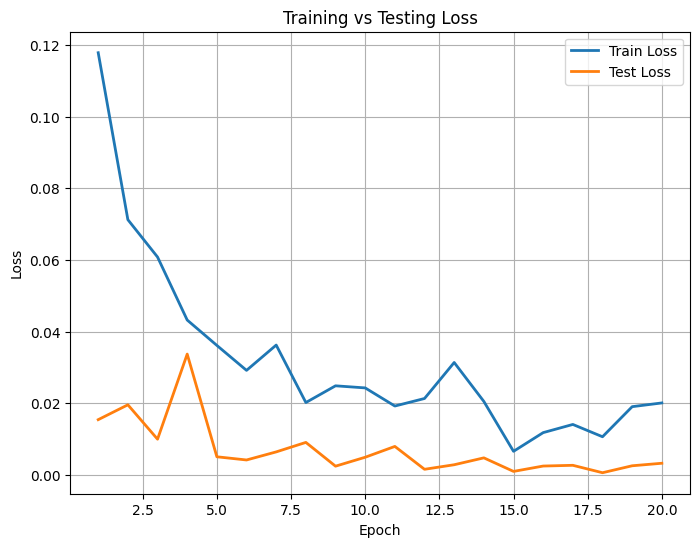

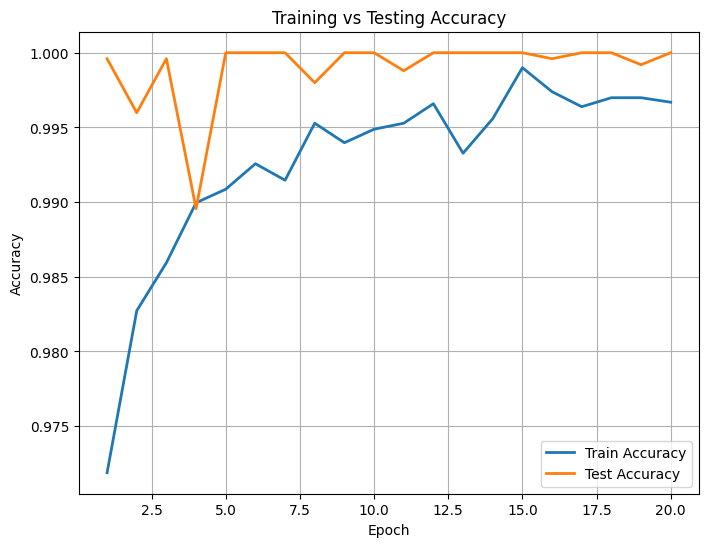

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# PLOTS:
# 1. Confusion Matrix
# 2. Training vs Testing Loss
# 3. Training vs Testing Accuracy
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay

# ============================================================
# 1. LOAD METRICS
# ============================================================

metrics_df = pd.read_csv("/content/training_metrics.csv")

cm_df = pd.read_csv("/content/confusion_matrix.csv")

cm = cm_df.values

# ============================================================
# 2. CLASS NAMES
# ============================================================

classes = [
    "Cyst",
    "Normal",
    "Stone",
    "Tumor"
]

# ============================================================
# 3. CONFUSION MATRIX PLOT
# ============================================================

plt.figure(figsize=(8,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(cmap='Blues', values_format='d')

plt.title("Confusion Matrix")

plt.savefig(
    "/content/confusion_matrix_plot.png",
    bbox_inches='tight'
)

plt.show()

# ============================================================
# 4. TRAINING vs TESTING LOSS
# ============================================================

plt.figure(figsize=(8,6))

plt.plot(
    metrics_df["epoch"],
    metrics_df["train_loss"],
    label="Train Loss",
    linewidth=2
)

plt.plot(
    metrics_df["epoch"],
    metrics_df["test_loss"],
    label="Test Loss",
    linewidth=2
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Testing Loss")

plt.legend()

plt.grid(True)

plt.savefig(
    "/content/loss_curve.png",
    bbox_inches='tight'
)

plt.show()

# ============================================================
# 5. TRAINING vs TESTING ACCURACY
# ============================================================

plt.figure(figsize=(8,6))

plt.plot(
    metrics_df["epoch"],
    metrics_df["train_acc"],
    label="Train Accuracy",
    linewidth=2
)

plt.plot(
    metrics_df["epoch"],
    metrics_df["test_acc"],
    label="Test Accuracy",
    linewidth=2
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training vs Testing Accuracy")

plt.legend()

plt.grid(True)

plt.savefig(
    "/content/accuracy_curve.png",
    bbox_inches='tight'
)

plt.show()

# ============================================================
# 6. OPTIONAL: DOWNLOAD PLOTS
# ============================================================

from google.colab import files

files.download("/content/confusion_matrix_plot.png")

files.download("/content/loss_curve.png")

files.download("/content/accuracy_curve.png")

          0         1         2         3         4         5         6  \
0  0.134928  0.103983 -0.056753  0.017983  0.450182 -0.025722  0.345747   
1  0.171805  0.097591 -0.057688  0.028454  0.386614  0.004373  0.329524   
2  0.195704  0.103966 -0.041592  0.007879  0.415178  0.035486  0.359714   
3  0.188422  0.096016 -0.051706  0.025537  0.376275  0.022052  0.335270   
4  0.195367  0.105700 -0.042385  0.006880  0.414288  0.035667  0.361854   

          7         8         9  ...       504       505       506       507  \
0 -0.320645  0.254519 -0.032868  ...  0.100827 -0.409116 -0.029614 -0.211112   
1 -0.234250  0.204942 -0.016900  ...  0.295619  0.264038 -0.758220 -0.756088   
2 -0.252215  0.251803 -0.067871  ...  0.284612  0.522260 -0.451032 -0.651841   
3 -0.215113  0.204237 -0.024905  ... -0.888728 -1.152213 -0.979815  0.511107   
4 -0.253996  0.251048 -0.068265  ...  0.318068  0.470986 -0.800995 -0.471675   

        508       509       510       511  label  prediction  
0  0.

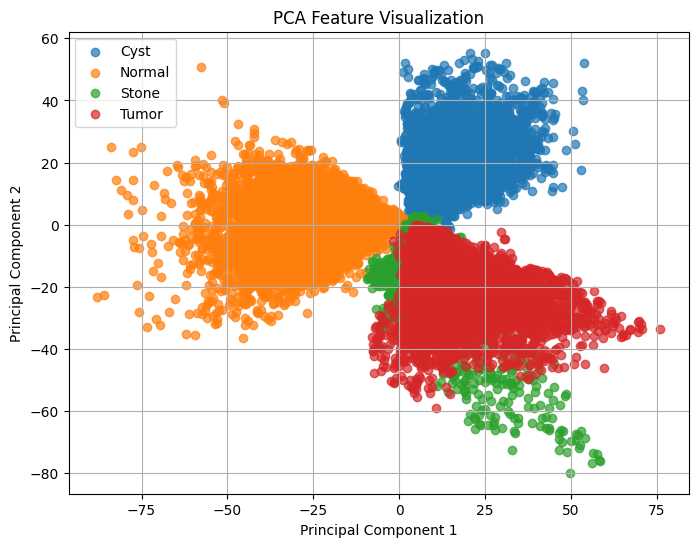


Running t-SNE...
t-SNE Completed!


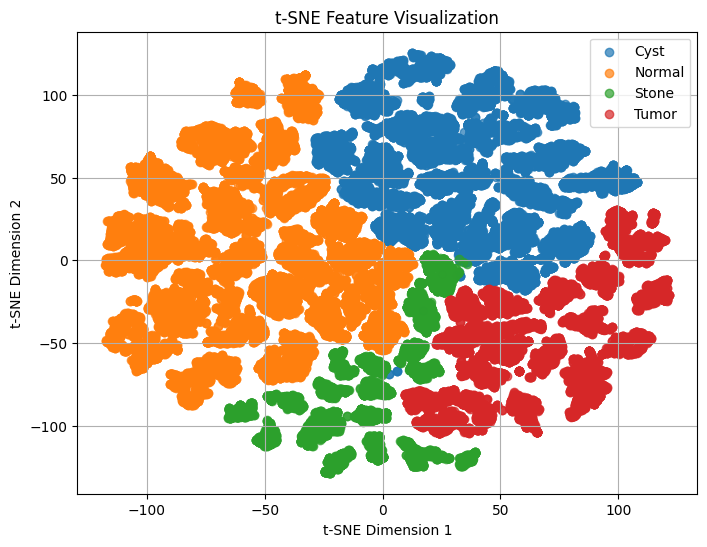


Explained Variance Ratio:
[0.44728428 0.29103527]

Total Explained Variance: 73.83%


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# PCA & t-SNE FEATURE VISUALIZATION
# ============================================================

# This code uses:
# feature_embeddings.csv
#
# Saved earlier during evaluation
#
# Generates:
# 1. PCA Plot
# 2. t-SNE Plot
# ============================================================

# ============================================================
# 1. IMPORTS
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

from sklearn.manifold import TSNE

# ============================================================
# 2. LOAD FEATURE EMBEDDINGS
# ============================================================

feature_df = pd.read_csv(
    "/content/feature_embeddings.csv"
)

print(feature_df.head())

# ============================================================
# 3. SEPARATE FEATURES & LABELS
# ============================================================

# Remove label & prediction columns
X = feature_df.drop(
    columns=["label", "prediction"]
).values

# Labels
# ============================================================
# Convert Numeric Labels to Actual Class Names
# ============================================================

label_map = {

    0: "Cyst",

    1: "Normal",

    2: "Stone",

    3: "Tumor"
}

# Convert labels
y_numeric = feature_df["label"].values

y = np.array([
    label_map[label]
    for label in y_numeric
])

print("\nFeature Shape:", X.shape)

print("Labels Shape :", y.shape)

# ============================================================
# 4. PCA (2D)
# ============================================================

print("\nRunning PCA...")

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

print("PCA Completed!")

# ============================================================
# 5. PCA PLOT
# ============================================================

plt.figure(figsize=(8,6))

classes = np.unique(y)

for cls in classes:

    idx = y == cls

    plt.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        label=cls,
        alpha=0.7
    )

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title("PCA Feature Visualization")

plt.legend()

plt.grid(True)

plt.savefig(
    "/content/pca_plot.png",
    bbox_inches='tight'
)

plt.show()

# ============================================================
# 6. t-SNE
# ============================================================

print("\nRunning t-SNE...")

tsne = TSNE(

    n_components=2,

    perplexity=30,

    learning_rate='auto',

    init='pca',

    random_state=42
)

X_tsne = tsne.fit_transform(X)

print("t-SNE Completed!")

# ============================================================
# 7. t-SNE PLOT
# ============================================================

plt.figure(figsize=(8,6))

for cls in classes:

    idx = y == cls

    plt.scatter(
        X_tsne[idx, 0],
        X_tsne[idx, 1],
        label=cls,
        alpha=0.7
    )

plt.xlabel("t-SNE Dimension 1")

plt.ylabel("t-SNE Dimension 2")

plt.title("t-SNE Feature Visualization")

plt.legend()

plt.grid(True)

plt.savefig(
    "/content/tsne_plot.png",
    bbox_inches='tight'
)

plt.show()

# ============================================================
# 8. EXPLAINED VARIANCE (OPTIONAL)
# ============================================================

explained_variance = pca.explained_variance_ratio_

print("\nExplained Variance Ratio:")

print(explained_variance)

print(
    f"\nTotal Explained Variance: "
    f"{np.sum(explained_variance)*100:.2f}%"
)

# ============================================================
# 9. DOWNLOAD PLOTS
# ============================================================

from google.colab import files

files.download("/content/pca_plot.png")

files.download("/content/tsne_plot.png")